In [1]:
import matplotlib.pyplot as plt
import matplotlib
import json
from pathlib import Path
from collections import OrderedDict
from modules.utils import compare_preds, format_time, natural_casing
from typing import NamedTuple

import abc
import pandas as pd
import time
import pprint
import textwrap

## Load Dataset

Read all splits and concat them

In [2]:
csv_read_args = dict(keep_default_na=False, dtype=str, na_values=[""])

bzkopen_train = pd.read_csv("open_data/bzkopen_addresses_train.csv", **csv_read_args)
bzkopen_val = pd.read_csv("open_data/bzkopen_addresses_val.csv", **csv_read_args)
bzkopen_test = pd.read_csv("open_data/bzkopen_addresses_test.csv", **csv_read_args)
bzkopen_merged : pd.DataFrame = pd.concat(
    [bzkopen_train, bzkopen_val, bzkopen_test], 
    keys=['train', 'val', 'test'], 
    names=['split', 'row']
)
bzkopen_merged

field  \
split row                            
train 0        ApplicantBirthPlace   
      1    ApplicantCurrentAddress   
      2        ApplicantBirthPlace   
      3    ApplicantCurrentAddress   
      4           VictimBirthPlace   
...                            ...   
test  163      ApplicantBirthPlace   
      164  ApplicantCurrentAddress   
      165      ApplicantBirthPlace   
      166  ApplicantCurrentAddress   
      167         VictimBirthPlace   

                                                 FullAddress UnitNumber  \
split row                                                                 
train 0                                              Ruskowa        NaN   
      1                170 Clymer Street, Brooklyn, N.Y. USA        NaN   
      2                                            Drohobycz        NaN   
      3                 London N.W.3/England, 109 Green Hill        NaN   
      4                                              Dresden        NaN   
...                                                      ...        ...   
test  163                                             Berlin        NaN   
      164                            Tiberias/Israel, Box 90        NaN   
      165                                        Delmenhorst        NaN   
      166  East-Ormund - Melbourne - Vic./Australia, 53 L...        NaN   
      167                                              Berne        NaN   

          HouseNumber      StreetName Neighborhood         City District  \
split row                                                                  
train 0           NaN             NaN          NaN      Ruskowa      NaN   
      1           170   Clymer Street     Brooklyn         N.Y.      NaN   
      2           NaN             NaN          NaN    Drohobycz      NaN   
      3           109      Green Hill          NaN       London      NaN   
      4           NaN             NaN          NaN      Dresden      NaN   
...               ...             ...          ...          ...      ...   
test  163         NaN             NaN          NaN       Berlin      NaN   
      164          90             Box          NaN     Tiberias      NaN   
      165         NaN             NaN          NaN  Delmenhorst      NaN   
      166          53  Lancaster Str.  East-Ormund    Melbourne      NaN   
      167         NaN             NaN          NaN        Berne      NaN   

            Region State    Country    PostalCode  
split row                                          
train 0        NaN   NaN        NaN           NaN  
      1        NaN   NaN        USA           NaN  
      2        NaN   NaN        NaN           NaN  
      3    England   NaN        NaN  London N.W.3  
      4        NaN   NaN        NaN           NaN  
...            ...   ...        ...           ...  
test  163      NaN   NaN        NaN           NaN  
      164      NaN   NaN     Israel           NaN  
      165      NaN   NaN        NaN           NaN  
      166      NaN  Vic.  Australia           NaN  
      167      NaN   NaN        NaN           NaN  

[1091 rows x 12 columns]

# Dataset Statistics

In [3]:
dataset_statistics = pd.concat(
    [
        bzkopen_merged[["FullAddress"]].rename(columns={"FullAddress": "AllAddresses"}),
        bzkopen_merged.pivot(columns="field", values="FullAddress"),
        bzkopen_merged.drop(columns=["field", "FullAddress"]),
    ]
).describe(include='all').T.drop(columns=["top", "freq"]).rename(index=natural_casing)

display(dataset_statistics)

,count,unique
All Addresses,1091,959
Applicant Birth Place,344,296
Applicant Current Address,354,344
Victim Birth Place,175,153
Victim Current Address,135,134
Victim Death Place,83,68
Unit Number,52,41
House Number,422,210
Street Name,425,391
Neighborhood,100,84


In [4]:
display(bzkopen_merged["Country"].value_counts().to_frame())

,count
Country,
Polen,66
Israel,60
USA,38
Rumänien,12
Ungarn,10
CSR,9
Argentinien,7
Rum.,7
Russland,7


In [5]:
country_normalize_mapping = {
    ("Polen", "Po.") : "Poland", ("USA.", "U.S.A.") : "USA", ("Isr.",) : "Israel", 
    ("Rumänien", "Rumaenien", "Rum.", "Rum. jetzt SSRU") : "Romania", 
    ("Ungarn", "Ung.", "Ungarn."): "Hungary", ("Brasilien", "Bras.") : "Brazil",
    ("Bulg.",) : "Bulgaria", ("Russland",) : "Russia", ("CSR",) : "Czechslovakia", 
    ("Argentinien", "Argenti- nien", "Argent.") : "Argentina", ("Frankreich", "Frankr.") : "France", 
    ("Australien", "Austr.") : "Australia", ("Schweiz",) : "Switzerland", ("Schweden",) : "Sweden", 
    ("Türkey",) : "Turkey", ("Österreich", "Österr.") : "Austria", ("Griechenland", "Griechenld") : "Greece",
    ("Italien",) : "Italy", ("Jug.", "Jugoslavien", "Jugl.") : "Yugoslavia", ("Norwegen") : "Norway",
    ("Mo.",) : "Monaco", ("Lettland",) : "Latvia", ("Litauen",) : "Lithuania"
}

country_normalize_mapping = {
    alias.lower() : normalized 
    for aliases, normalized in country_normalize_mapping.items() 
    for alias in aliases
} | {
    normalized.lower() : normalized
    for normalized in country_normalize_mapping.values()
}

normalized_country = bzkopen_merged["Country"].apply(
    lambda c: country_normalize_mapping.get(c.lower(), c) if isinstance(c, str) else "No Country"
)
country_counts = normalized_country.value_counts().to_frame()
display(country_counts)

,count
Country,
No Country,785
Poland,69
Israel,65
USA,48
Romania,22
Hungary,12
Russia,11
Argentina,10
France,9


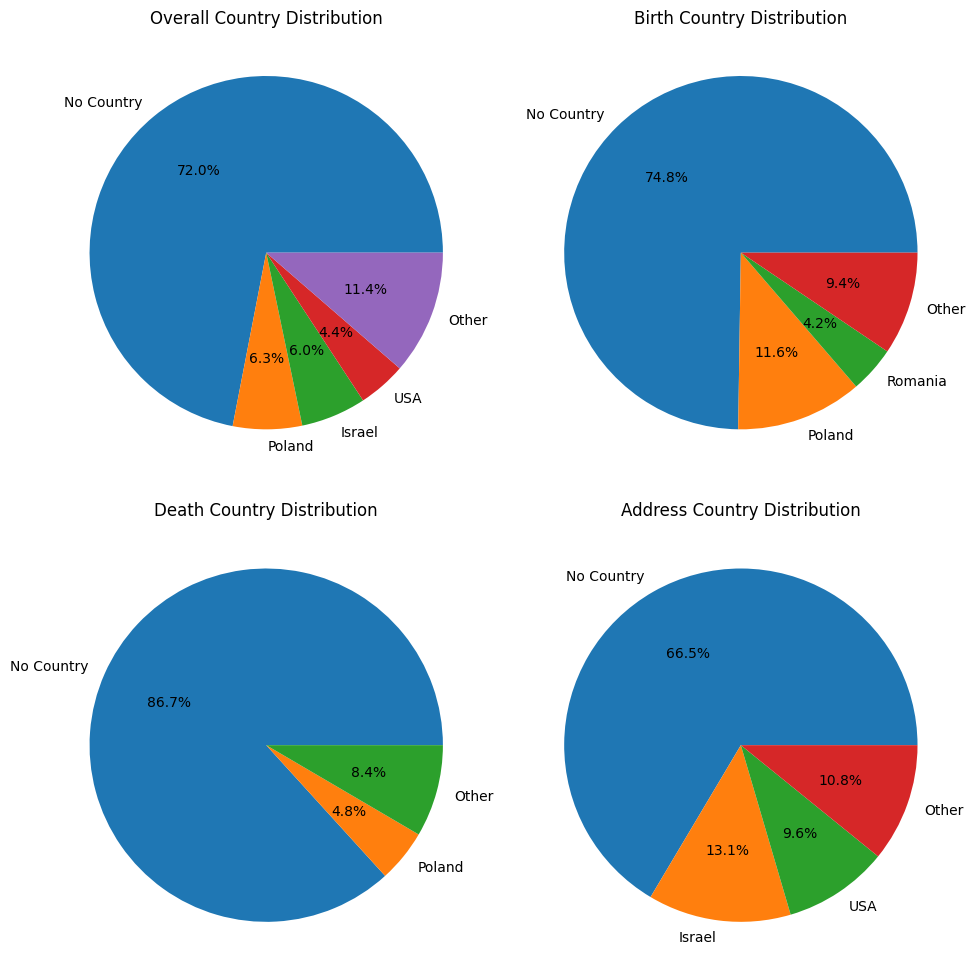

In [6]:
def summarize_counts(counts: pd.DataFrame, thresh: float = 0.04) -> pd.DataFrame:
    mask = (counts["count"] / counts["count"].sum()) >= thresh
    summarized_counts = counts[mask]
    summarized_counts.loc["Other"] = counts[~mask].sum()
    return summarized_counts
summarized_country_counts = summarize_counts(country_counts)

country_per_field_type = bzkopen_merged[["field"]].merge(
    normalized_country, left_index=True, right_index=True
)
birth_country_counts = country_per_field_type[country_per_field_type["field"].str.contains("Birth")]["Country"].value_counts().to_frame()
birth_country_counts = summarize_counts(birth_country_counts)
death_country_counts = country_per_field_type[country_per_field_type["field"].str.contains("Death")]["Country"].value_counts().to_frame()
death_country_counts = summarize_counts(death_country_counts)
address_country_counts = country_per_field_type[country_per_field_type["field"].str.contains("Address")]["Country"].value_counts().to_frame()
address_country_counts = summarize_counts(address_country_counts)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
summarized_country_counts["count"].plot(kind="pie", autopct="%1.1f%%", ax=axes[0, 0], title="Overall Country Distribution")
birth_country_counts["count"].plot(kind="pie", autopct="%1.1f%%", ax=axes[0, 1], title="Birth Country Distribution")
death_country_counts["count"].plot(kind="pie", autopct="%1.1f%%", ax=axes[1, 0], title="Death Country Distribution")
address_country_counts["count"].plot(kind="pie", autopct="%1.1f%%", ax=axes[1, 1], title="Address Country Distribution")
plt.tight_layout()